<a href="https://colab.research.google.com/github/Dimitradag/advertistingdataset_emme/blob/main/Advertising_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving advertising.csv to advertising (3).csv
Ολόκληρο το Dataset:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5



--- Συντελεστές (Coefficients) ---
TV: 0.0545
Radio: 0.1009
Newspaper: 0.0043

--- Αξιολόγηση Μοντέλου ---
Mean Squared Error (MSE): 2.91
Mean Absolute Error (MAE): 1.27
R-squared (R2 Score): 0.9059


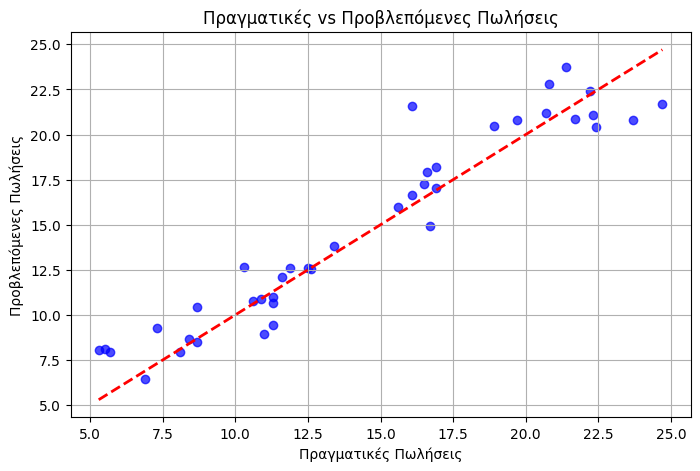

In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Φόρτωση των δεδομένων απευθείας από το αρχείο
df = pd.read_csv('advertising.csv')


# Εμφάνιση ολόκληρου του Dataset
print("Ολόκληρο το Dataset:")
display(df)

# 2. Ορισμός ανεξάρτητων μεταβλητών (X) και εξαρτημένης (y)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 3. Διαχωρισμός δεδομένων (80% Εκπαίδευση, 20% Δοκιμή)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Εκπαίδευση Μοντέλου
model = LinearRegression()
model.fit(X_train, y_train)

print("\n--- Συντελεστές (Coefficients) ---")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

# 5. Πρόβλεψη
y_pred = model.predict(X_test)

# 6. Αξιολόγηση
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Αξιολόγηση Μοντέλου ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# 7. Οπτικοποίηση
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Πραγματικές Πωλήσεις')
plt.ylabel('Προβλεπόμενες Πωλήσεις')
plt.title('Πραγματικές vs Προβλεπόμενες Πωλήσεις')
plt.grid(True)
plt.show()